In [37]:
import nltk
import pandas as pd

from nltk.tree import Tree


In [38]:
df=pd.read_csv('/content/bbc_news_data - bbc_news_data.csv')

In [39]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [40]:
sentence = """At eight o'clock on Thursday morning Arthur didn't feel very good."""
tokens = nltk.word_tokenize(sentence)


In [41]:
# from nltk.corpus import stopwords
# stop_words = set(stopwords.words('english'))
# [word for word in ["i","love","nlp"] if word not in stopwords]


from nltk.stem import PorterStemmer
ps = PorterStemmer()
ps.stem("playing")

'play'

In [42]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [43]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [44]:
tokens
tagged = nltk.pos_tag(tokens)
tagged[0:6]


[('At', 'IN'),
 ('eight', 'CD'),
 ("o'clock", 'NN'),
 ('on', 'IN'),
 ('Thursday', 'NNP'),
 ('morning', 'NN')]

In [45]:
import nltk
nltk.download('words')

[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!


True

In [46]:
import nltk
nltk.download('maxent_ne_chunker_tab')


[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker_tab is already up-to-date!


True

In [53]:
pip install svgling

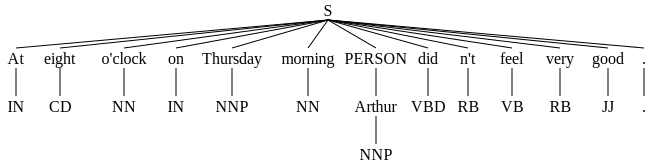

In [55]:
entities = nltk.chunk.ne_chunk(tagged)
entities

In [56]:
tree = Tree('S', [('At', 'IN'), ('eight', 'CD'), ("o'clock", 'NN'), ('on', 'IN'),
                  ('Thursday', 'NNP'), ('morning', 'NN'),
                  Tree('PERSON', [('Arthur', 'NNP')]), ('did', 'VBD'), ("n't", 'RB'),
                  ('feel', 'VB'), ('very', 'RB'), ('good', 'JJ'), ('.', '.')])

tree.pretty_print()


                                                           S                                                 
   ________________________________________________________|___________________________________________       
  |      |         |        |        |           |         |      |       |       |       |     |    PERSON  
  |      |         |        |        |           |         |      |       |       |       |     |      |      
At/IN eight/CD o'clock/NN on/IN Thursday/NNP morning/NN did/VBD n't/RB feel/VB very/RB good/JJ ./. Arthur/NNP



In [57]:
import nltk
nltk.download('treebank')

[nltk_data] Downloading package treebank to /root/nltk_data...
[nltk_data]   Package treebank is already up-to-date!


True

In [60]:
from nltk.corpus import treebank
t = treebank.parsed_sents('wsj_0001.mrg')[0]

# The t.draw() method requires a graphical display, which is not available in Colab.
# To visualize the tree, we can use pretty_print() for a text representation
# or svgling for an inline SVG image.

# Option 1: pretty_print() for text-based output
t.pretty_print()

# Option 2: Use svgling to render as SVG (assuming svgling is installed)
# from svgling.draw import draw_tree
# draw_tree(t)


                                                     S                                                                         
                         ____________________________|_______________________________________________________________________   
                        |                                               VP                                                   | 
                        |                        _______________________|___                                                 |  
                      NP-SBJ                    |                           VP                                               | 
         _______________|___________________    |     ______________________|______________________________________          |  
        |          |              ADJP      |   |    |        |                PP-CLR                              |         | 
        |          |           ____|____    |   |    |        |          ________|_________          

In [61]:
# Extract named entities
named_entities = []
for subtree in tree.subtrees():
    if subtree.label() == 'PERSON':  # Check for PERSON entities
        named_entities.append(' '.join(word for word, tag in subtree))

print("Named Entities:", named_entities)

Named Entities: ['Arthur']


In [62]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [63]:
# Extract words from the tree
words = [word for word, pos in tree.leaves()]

In [64]:
# Combine words into a single string
text_data = " ".join(words)


In [65]:
# Create a WordCloud object
wordcloud = WordCloud(width=800, height=800, background_color='white', colormap='viridis').generate(text_data)


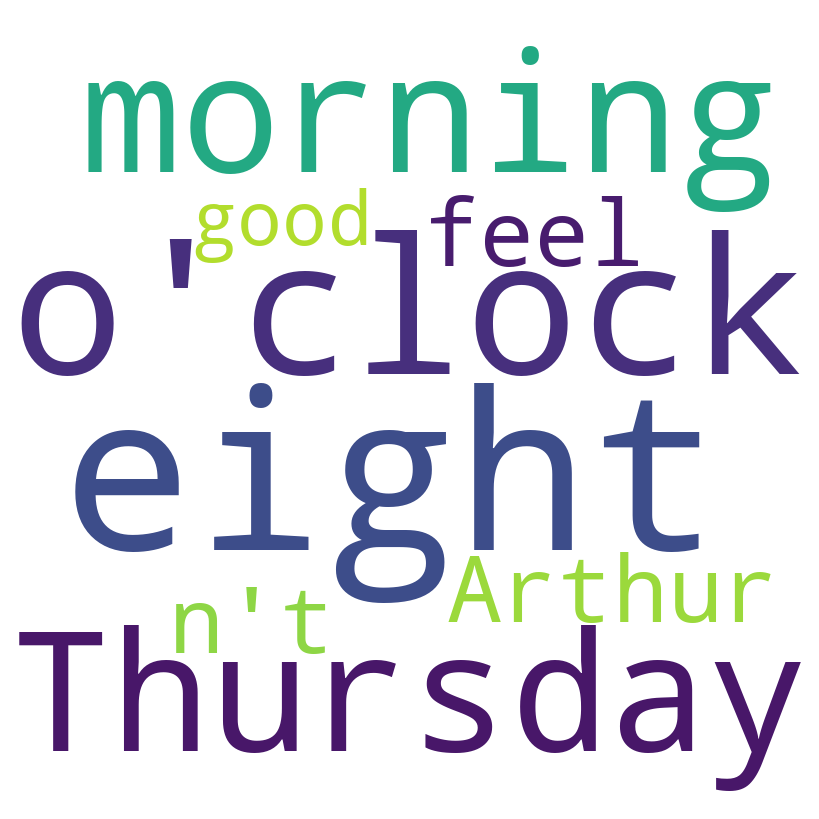

In [66]:
# Plot the WordCloud image
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.tight_layout(pad=0)


In [67]:
# Display the word cloud
plt.show()